# 02 — Câncer e COVID-19 na Região Metropolitana de São Paulo

## Pergunta central
Como os registros mensais de câncer de pulmão (C34), leucemia linfoide (C91), leucemia mieloide (C92) e COVID-19 (U07.1) se comportam em Campinas, Guarulhos e São Paulo?

Esta é uma análise **descritiva e exploratória**. Os dados são contagens registradas, não taxas populacionais; correlação temporal não estabelece causalidade.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from cancer_covid.analysis import (coverage_summary, correlations_with_covid, pandemic_period_comparison, totals_by_city_and_diagnosis)
from cancer_covid.data import load_processed_data
from cancer_covid.plots import plot_cancer_series, plot_covid_series, plot_totals, set_theme

set_theme()
dados = load_processed_data()


## Pergunta 1 — Qual é a cobertura dos dados?

Antes de comparar municípios, verificamos se eles cobrem o mesmo período e têm o mesmo número de meses observados.

In [2]:
coverage_summary(dados)


,city,inicio,fim,meses
0,Campinas,2018-01-01,2023-03-01,63
1,Guarulhos,2018-01-01,2023-03-01,63
2,São Paulo,2018-01-01,2023-03-01,63


**Resposta.** A tabela informa exatamente o período disponível em cada cidade. Comparações devem sempre ficar restritas à interseção desses períodos.

## Pergunta 2 — Quais diagnósticos concentram mais registros?

Os totais ajudam a caracterizar o conjunto, mas não permitem comparar risco entre cidades, pois não foram ajustados por população.

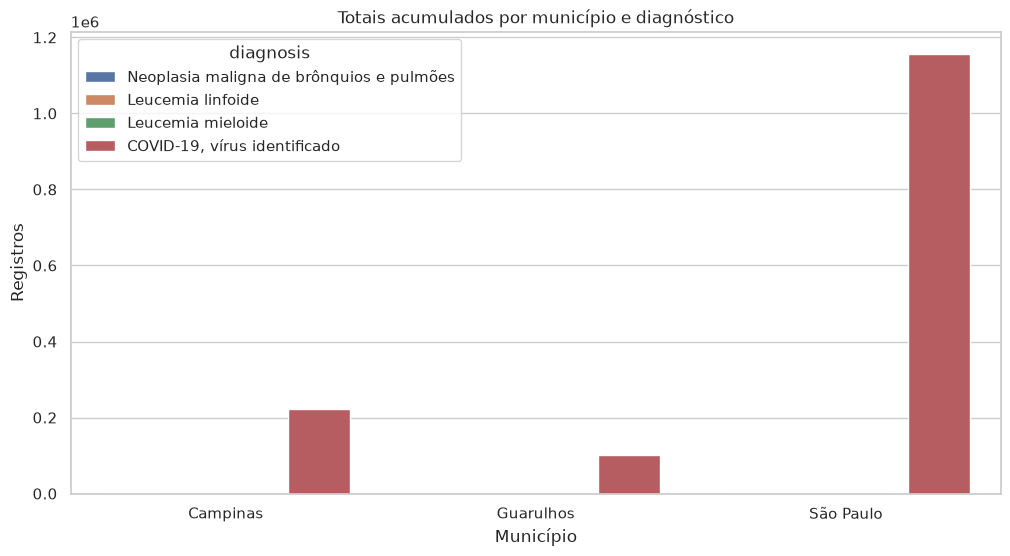

In [3]:
totals_by_city_and_diagnosis(dados).pivot(index='city', columns='diagnosis', values='count')
plot_totals(dados);


## Pergunta 3 — Quando ocorreram os picos de COVID-19?

A série temporal revela a dinâmica dos registros de U07.1 e oferece contexto para a leitura das séries oncológicas.

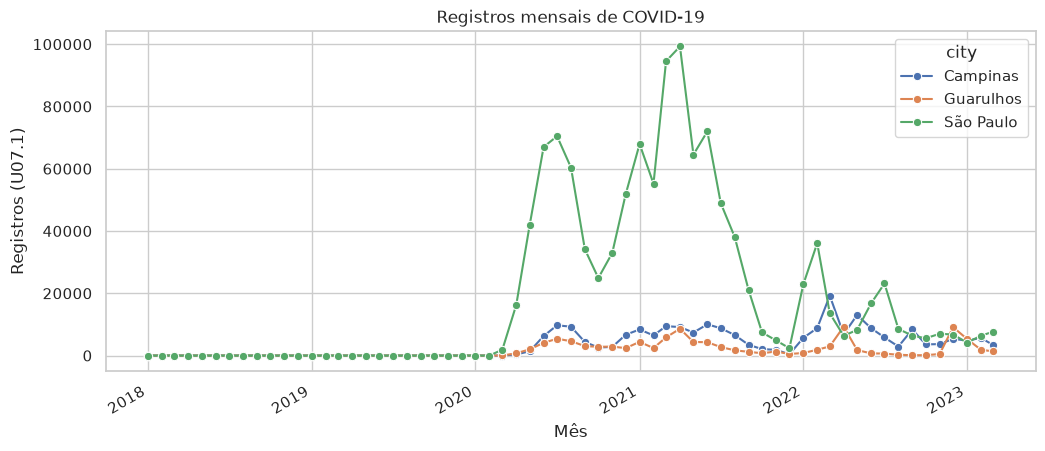

In [4]:
plot_covid_series(dados);


## Pergunta 4 — As séries de câncer mudaram ao longo do período?

Examine cada município separadamente: as escalas variam, e misturá-las pode esconder oscilações importantes.

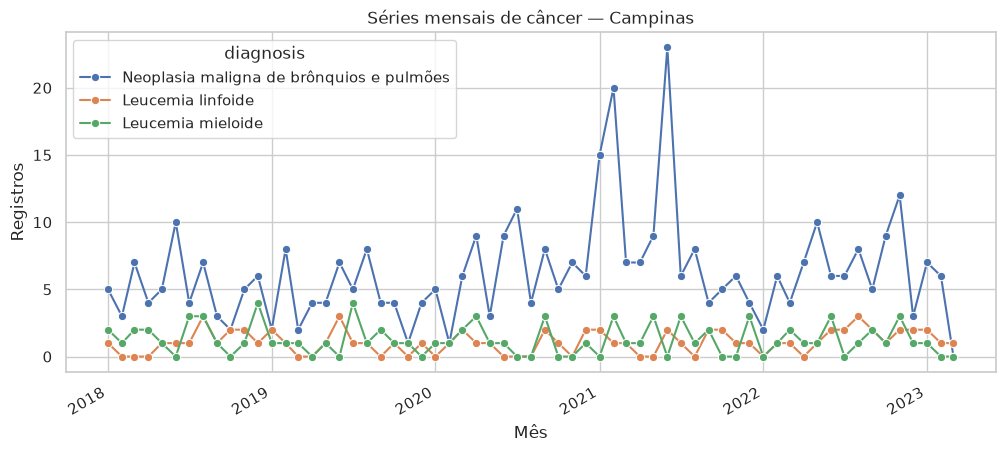

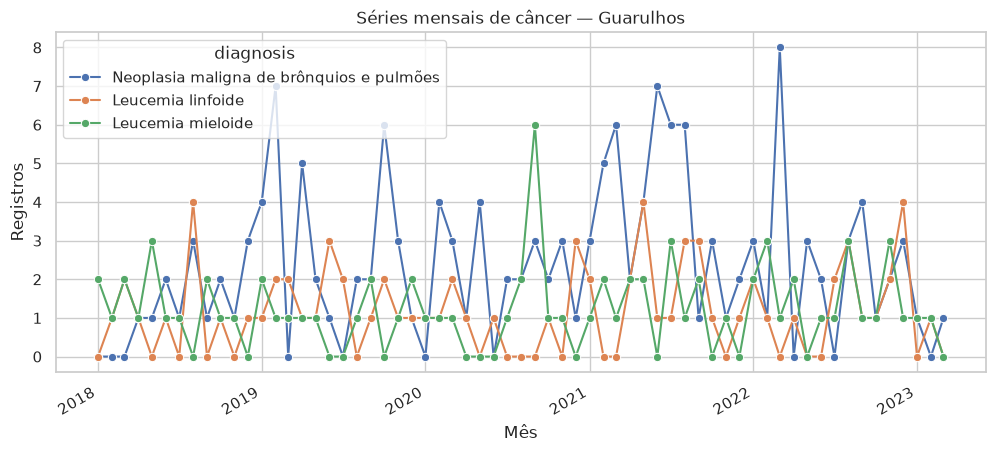

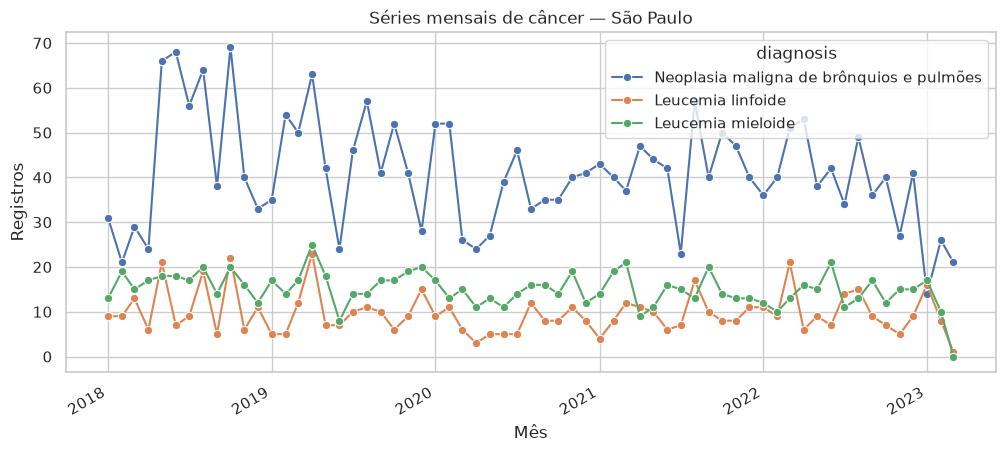

In [5]:
for cidade in sorted(dados['city'].unique()):
    plot_cancer_series(dados, cidade);


## Pergunta 5 — Há associação linear contemporânea entre COVID-19 e os registros de câncer?

Calculamos a correlação de Pearson entre contagens do mesmo mês. O resultado não mede causalidade, não controla sazonalidade ou população e pode deixar de captar efeitos defasados.

In [6]:
correlations_with_covid(dados).pivot(index='city', columns='diagnosis', values='correlation').round(2)


diagnosis,C34,C91,C92
city,,,
Campinas,0.37,-0.02,-0.05
Guarulhos,0.13,0.06,0.11
São Paulo,-0.08,-0.13,-0.15


**Resposta.** Use os coeficientes apenas como evidência exploratória de co-variação. Uma conclusão sobre impacto exigiria taxas, população de referência, controle de sazonalidade, acesso ao diagnóstico e desenho causal.

## Pergunta 6 — Como as médias mensais diferem antes e após o início da pandemia?

A comparação abaixo é uma descrição simples, com março de 2020 como marco. Ela não é teste de hipótese nem estimativa de efeito.

In [7]:
pandemic_period_comparison(dados).pivot(index=['city', 'diagnosis'], columns='period', values='media_mensal').round(2)


period               Antes da pandemia  Pandemia e pós-início
city      diagnosis                                          
Campinas  C34                     4.62                   7.38
          C91                     0.96                   1.16
          C92                     1.35                   1.22
Guarulhos C34                     2.00                   2.68
          C91                     1.15                   1.19
          C92                     1.12                   1.30
São Paulo C34                    45.23                  37.95
          C91                    10.65                   8.92
          C92                    16.50                  13.95

## Conclusão e próximos passos

O notebook descreve padrões, picos e associações simples nas contagens disponíveis. Para investigar impacto da pandemia, o próximo passo é incorporar denominadores populacionais e histórico de acesso/registro em saúde, testar defasagens e definir uma estratégia causal antes de atribuir mudanças à COVID-19.